# 🧠 Notebook 2: EEGNet — Deep CNN for Alzheimer's Classification
**Model**: EEGNet-inspired 1D/2D Convolutional Neural Network

**Architecture**: Temporal convolution → Depthwise spatial convolution → Separable convolution → Classification

**Training**: GPU-accelerated, Stratified Group K-Fold cross-validation, class-weighted loss

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_curve, auc, accuracy_score, f1_score)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import json, time, warnings
from pathlib import Path

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.figsize': (12, 6), 'figure.dpi': 100, 'font.size': 12, 'figure.facecolor': 'white'})
sns.set_style("whitegrid")

BASE_DIR = Path('/home/aditya11/Documents/playground/be_proj_final')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️ Device: {DEVICE}" + (f" ({torch.cuda.get_device_name(0)})" if torch.cuda.is_available() else ""))

🖥️ Device: cuda (NVIDIA GeForce RTX 4050 Laptop GPU)


## 1. Load Preprocessed Data

In [2]:
data = np.load(BASE_DIR / 'processed_data' / 'eeg_preprocessed.npz')
X, y, groups = data['X'], data['y'], data['groups']
with open(BASE_DIR / 'processed_data' / 'preprocessing_info.json') as f:
    info = json.load(f)

N_CHANNELS, N_TIMEPOINTS = X.shape[1], X.shape[2]
N_CLASSES = 3
CLASS_NAMES = info['class_names']
print(f"📦 Data: {X.shape[0]} epochs, {N_CHANNELS} channels, {N_TIMEPOINTS} timepoints")
print(f"   Classes: {dict(zip(CLASS_NAMES, [int(np.sum(y==i)) for i in range(N_CLASSES)]))}")

📦 Data: 17021 epochs, 19 channels, 1024 timepoints
   Classes: {'AD': 7122, 'HC': 5907, 'FTD': 3992}


## 2. EEGNet Model Architecture
Based on Lawhern et al. (2018), adapted for multi-class Alzheimer's classification.

In [3]:
class EEGNet(nn.Module):
    def __init__(self, n_channels, n_timepoints, n_classes, F1=16, D=2, F2=32, kernel_length=64, dropout=0.3):
        super().__init__()
        # Block 1: Temporal + Spatial filtering
        self.conv1 = nn.Conv2d(1, F1, (1, kernel_length), padding=(0, kernel_length // 2), bias=False)
        self.bn1 = nn.BatchNorm2d(F1)
        self.depthwise = nn.Conv2d(F1, F1 * D, (n_channels, 1), groups=F1, bias=False)
        self.bn2 = nn.BatchNorm2d(F1 * D)
        self.pool1 = nn.AvgPool2d((1, 4))
        self.drop1 = nn.Dropout(dropout)
        # Block 2: Separable convolution
        self.separable1 = nn.Conv2d(F1 * D, F1 * D, (1, 16), padding=(0, 8), groups=F1 * D, bias=False)
        self.separable2 = nn.Conv2d(F1 * D, F2, (1, 1), bias=False)
        self.bn3 = nn.BatchNorm2d(F2)
        self.pool2 = nn.AvgPool2d((1, 8))
        self.drop2 = nn.Dropout(dropout)
        # Classifier
        fc_input = F2 * (n_timepoints // 32)
        self.fc = nn.Sequential(
            nn.Linear(fc_input, 128), nn.ELU(), nn.Dropout(dropout),
            nn.Linear(128, n_classes)
        )

    def forward(self, x):
        x = x.unsqueeze(1)  # (B, 1, C, T)
        x = self.bn1(self.conv1(x))
        x = F.elu(self.bn2(self.depthwise(x)))
        x = self.drop1(self.pool1(x))
        x = self.separable1(x)
        x = F.elu(self.bn3(self.separable2(x)))
        x = self.drop2(self.pool2(x))
        return self.fc(x.flatten(1))

class EEGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)
    def __len__(self): return len(self.y)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

model_test = EEGNet(N_CHANNELS, N_TIMEPOINTS, N_CLASSES).to(DEVICE)
total_params = sum(p.numel() for p in model_test.parameters())
print(f"📐 EEGNet Architecture:")
print(f"   Parameters: {total_params:,}")
print(model_test)
del model_test

📐 EEGNet Architecture:
   Parameters: 134,915
EEGNet(
  (conv1): Conv2d(1, 16, kernel_size=(1, 64), stride=(1, 1), padding=(0, 32), bias=False)
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (depthwise): Conv2d(16, 32, kernel_size=(19, 1), stride=(1, 1), groups=16, bias=False)
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): AvgPool2d(kernel_size=(1, 4), stride=(1, 4), padding=0)
  (drop1): Dropout(p=0.3, inplace=False)
  (separable1): Conv2d(32, 32, kernel_size=(1, 16), stride=(1, 1), padding=(0, 8), groups=32, bias=False)
  (separable2): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn3): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): AvgPool2d(kernel_size=(1, 8), stride=(1, 8), padding=0)
  (drop2): Dropout(p=0.3, inplace=False)
  (fc): Sequential(
    (0): Linear(in_features=1024, out_features=128, bias=True)
    (1): ELU(alph

## 3. Training with Stratified Group K-Fold Cross-Validation
We use 5-fold CV with group-aware stratification to prevent data leakage between subjects.

In [4]:
N_FOLDS = 5
EPOCHS = 50
BATCH_SIZE = 64
LR = 1e-3

# Class weights for imbalanced data
class_counts = np.bincount(y)
class_weights = torch.FloatTensor(1.0 / class_counts * len(y) / N_CLASSES).to(DEVICE)
print(f"⚖️ Class weights: {class_weights.cpu().numpy().round(3)}")

sgkf = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

fold_results = []
all_histories = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
all_test_preds, all_test_labels, all_test_probs = [], [], []

total_start = time.time()

for fold, (train_idx, test_idx) in enumerate(sgkf.split(X, y, groups)):
    print(f"\n{'='*60}")
    print(f"📂 Fold {fold + 1}/{N_FOLDS}")

    # Split train into train/val (90/10)
    n_val = max(1, len(train_idx) // 10)
    perm = np.random.RandomState(fold).permutation(len(train_idx))
    val_idx_local = train_idx[perm[:n_val]]
    train_idx_local = train_idx[perm[n_val:]]

    train_dl = DataLoader(EEGDataset(X[train_idx_local], y[train_idx_local]),
                          batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
    val_dl = DataLoader(EEGDataset(X[val_idx_local], y[val_idx_local]), batch_size=BATCH_SIZE)
    test_dl = DataLoader(EEGDataset(X[test_idx], y[test_idx]), batch_size=BATCH_SIZE)

    model = EEGNet(N_CHANNELS, N_TIMEPOINTS, N_CLASSES).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    hist = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc = 0
    patience_counter = 0

    for epoch in range(EPOCHS):
        # Train
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0
        for xb, yb in train_dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_loss += loss.item() * xb.size(0)
            train_correct += (out.argmax(1) == yb).sum().item()
            train_total += xb.size(0)
        scheduler.step()

        # Validate
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for xb, yb in val_dl:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                out = model(xb)
                val_loss += criterion(out, yb).item() * xb.size(0)
                val_correct += (out.argmax(1) == yb).sum().item()
                val_total += xb.size(0)

        t_loss = train_loss / max(train_total, 1)
        v_loss = val_loss / max(val_total, 1)
        t_acc = train_correct / max(train_total, 1)
        v_acc = val_correct / max(val_total, 1)
        hist['train_loss'].append(t_loss)
        hist['val_loss'].append(v_loss)
        hist['train_acc'].append(t_acc)
        hist['val_acc'].append(v_acc)

        if v_acc > best_val_acc:
            best_val_acc = v_acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if (epoch + 1) % 20 == 0:
            print(f"   Epoch {epoch+1}: train_loss={t_loss:.4f} val_acc={v_acc:.4f}")

        if patience_counter >= 15:
            print(f"   Early stopping at epoch {epoch+1}")
            break

    # Test with best model
    model.load_state_dict(best_state)
    model.eval()
    preds, labels, probs = [], [], []
    with torch.no_grad():
        for xb, yb in test_dl:
            xb = xb.to(DEVICE)
            out = model(xb)
            probs.append(F.softmax(out, dim=1).cpu().numpy())
            preds.append(out.argmax(1).cpu().numpy())
            labels.append(yb.numpy())

    preds = np.concatenate(preds)
    labels = np.concatenate(labels)
    probs_arr = np.concatenate(probs)

    fold_acc = accuracy_score(labels, preds)
    fold_f1 = f1_score(labels, preds, average='macro')
    fold_results.append({'fold': fold + 1, 'accuracy': fold_acc, 'f1_macro': fold_f1})
    print(f"   ✅ Fold {fold+1} — Accuracy: {fold_acc:.4f}, F1: {fold_f1:.4f}")

    all_test_preds.extend(preds)
    all_test_labels.extend(labels)
    all_test_probs.append(probs_arr)
    for k in hist:
        all_histories[k].append(hist[k])

    # Save best model from last fold
    if fold == N_FOLDS - 1:
        torch.save(best_state, BASE_DIR / 'models' / 'eegnet_best.pt')

total_time = time.time() - total_start
print(f"\n⏱️ Total training time: {total_time:.1f}s")

⚖️ Class weights: [0.797 0.96  1.421]

📂 Fold 1/5


   Epoch 20: train_loss=0.1162 val_acc=0.9644


   Epoch 40: train_loss=0.0579 val_acc=0.9840


   ✅ Fold 1 — Accuracy: 0.5341, F1: 0.5124

📂 Fold 2/5


   Epoch 20: train_loss=0.1342 val_acc=0.9755


...

   Epoch 40: train_loss=0.0514 val_acc=0.9809


   ✅ Fold 4 — Accuracy: 0.4839, F1: 0.4457

📂 Fold 5/5


   Epoch 20: train_loss=0.1550 val_acc=0.9660


   Epoch 40: train_loss=0.0784 val_acc=0.9815


   ✅ Fold 5 — Accuracy: 0.6619, F1: 0.5697

⏱️ Total training time: 814.8s


## 4. Training Curves

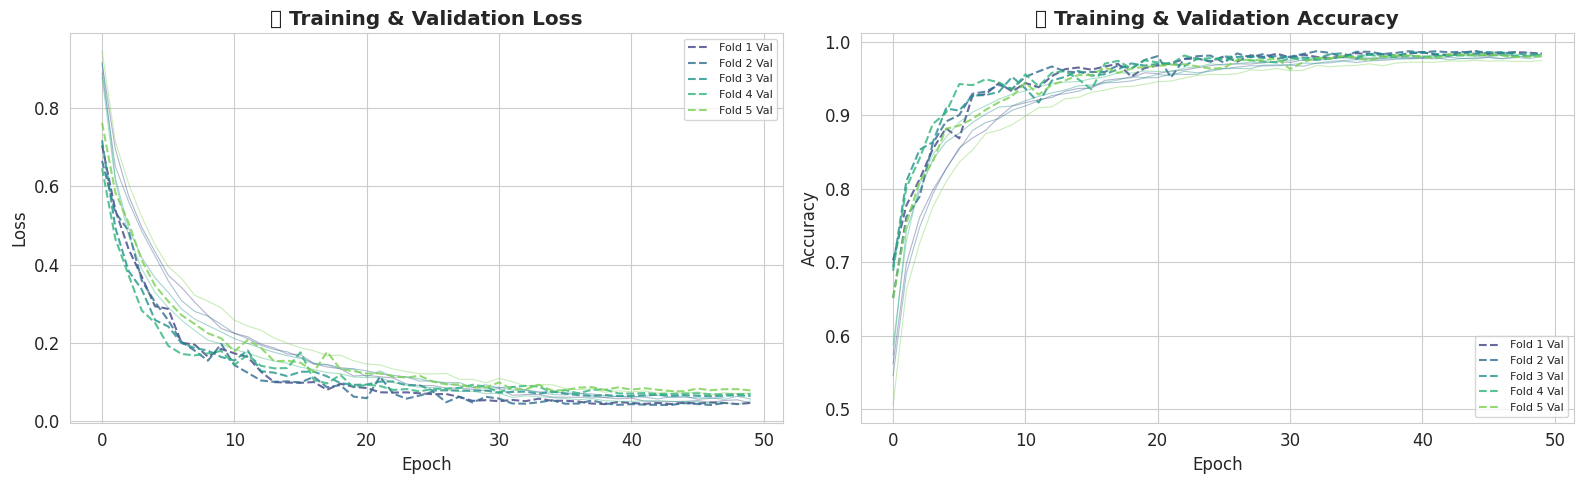

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
colors = plt.cm.viridis(np.linspace(0.2, 0.8, N_FOLDS))

for i in range(N_FOLDS):
    axes[0].plot(all_histories['train_loss'][i], color=colors[i], alpha=0.4, linewidth=0.8)
    axes[0].plot(all_histories['val_loss'][i], color=colors[i], alpha=0.8, linewidth=1.5,
                 linestyle='--', label=f'Fold {i+1} Val')
axes[0].set_title('📉 Training & Validation Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=8)

for i in range(N_FOLDS):
    axes[1].plot(all_histories['train_acc'][i], color=colors[i], alpha=0.4, linewidth=0.8)
    axes[1].plot(all_histories['val_acc'][i], color=colors[i], alpha=0.8, linewidth=1.5,
                 linestyle='--', label=f'Fold {i+1} Val')
axes[1].set_title('📈 Training & Validation Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(BASE_DIR / 'results' / 'cnn_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Evaluation Results

In [6]:
all_test_preds = np.array(all_test_preds)
all_test_labels = np.array(all_test_labels)
all_test_probs_cat = np.concatenate(all_test_probs)

# Classification Report
print("📊 Overall Classification Report (across all folds):\n")
report = classification_report(all_test_labels, all_test_preds, target_names=CLASS_NAMES, digits=4)
print(report)

# Cross-validation summary
results_df = pd.DataFrame(fold_results)
print(f"\n📈 Cross-Validation Summary:")
print(f"   Mean Accuracy: {results_df['accuracy'].mean():.4f} ± {results_df['accuracy'].std():.4f}")
print(f"   Mean F1 (macro): {results_df['f1_macro'].mean():.4f} ± {results_df['f1_macro'].std():.4f}")

📊 Overall Classification Report (across all folds):

              precision    recall  f1-score   support

          AD     0.6418    0.5817    0.6103      7122
          HC     0.6077    0.7042    0.6524      5907
         FTD     0.3687    0.3437    0.3558      3992

    accuracy                         0.5684     17021
   macro avg     0.5394    0.5432    0.5395     17021
weighted avg     0.5659    0.5684    0.5652     17021


📈 Cross-Validation Summary:
   Mean Accuracy: 0.5667 ± 0.0821
   Mean F1 (macro): 0.5266 ± 0.0722


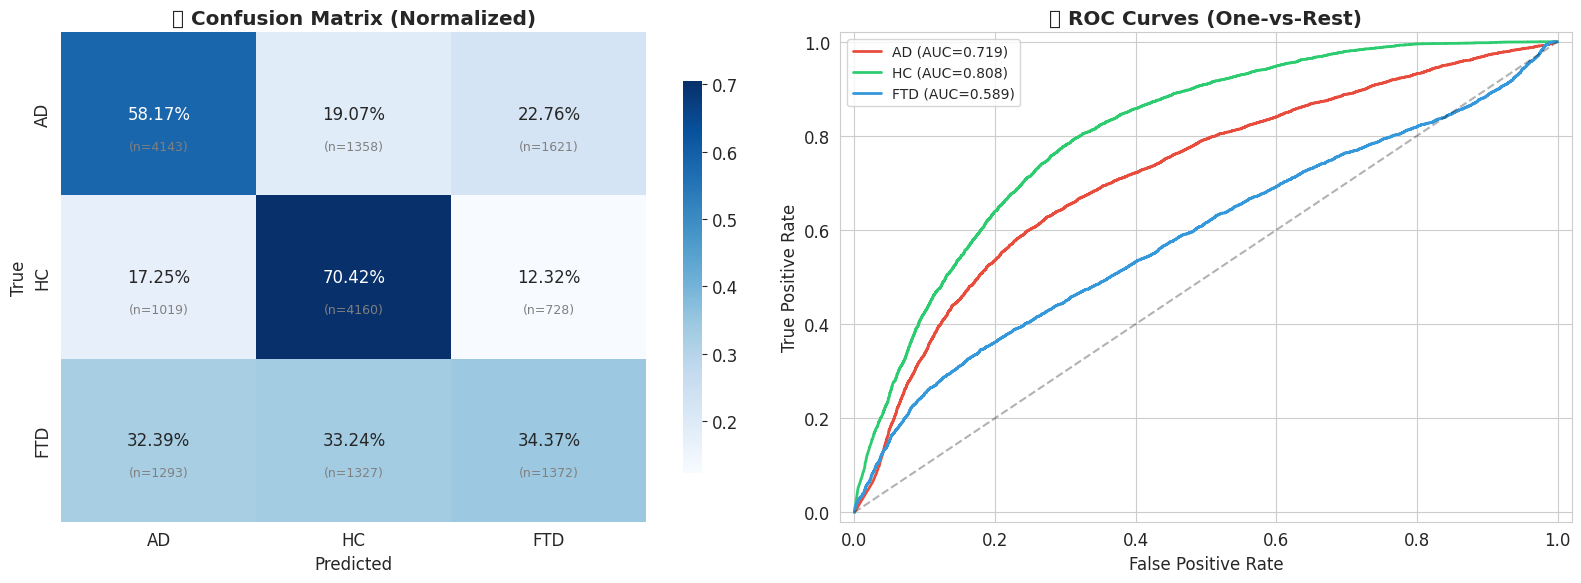

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion Matrix
cm = confusion_matrix(all_test_labels, all_test_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES, ax=axes[0], cbar_kws={'shrink': 0.8})
for i in range(len(cm)):
    for j in range(len(cm)):
        axes[0].text(j + 0.5, i + 0.7, f'(n={cm[i][j]})', ha='center', va='center', fontsize=9, color='gray')
axes[0].set_title('🎯 Confusion Matrix (Normalized)', fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

# ROC Curves
y_bin = label_binarize(all_test_labels, classes=[0, 1, 2])
colors_roc = ['#e74c3c', '#2ecc71', '#3498db']
for i, (cls_name, color) in enumerate(zip(CLASS_NAMES, colors_roc)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_test_probs_cat[:, i])
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color=color, linewidth=2, label=f'{cls_name} (AUC={roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[1].set_title('📊 ROC Curves (One-vs-Rest)', fontweight='bold')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=10)
axes[1].set_xlim([-0.02, 1.02]); axes[1].set_ylim([-0.02, 1.02])

plt.tight_layout()
plt.savefig(BASE_DIR / 'results' / 'cnn_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Save Results

In [8]:
cnn_results = {
    'model': 'EEGNet (CNN)',
    'mean_accuracy': float(results_df['accuracy'].mean()),
    'std_accuracy': float(results_df['accuracy'].std()),
    'mean_f1_macro': float(results_df['f1_macro'].mean()),
    'std_f1_macro': float(results_df['f1_macro'].std()),
    'fold_results': fold_results,
    'training_time_s': total_time,
    'n_params': total_params,
    'classification_report': classification_report(all_test_labels, all_test_preds,
                                                    target_names=CLASS_NAMES, output_dict=True)
}

with open(BASE_DIR / 'results' / 'cnn_results.json', 'w') as f:
    json.dump(cnn_results, f, indent=2, default=str)

np.savez(BASE_DIR / 'results' / 'cnn_predictions.npz',
         preds=all_test_preds, labels=all_test_labels, probs=all_test_probs_cat)

print(f"✅ CNN results saved!")
print(f"   Mean Accuracy: {cnn_results['mean_accuracy']:.4f}")
print(f"   Mean F1: {cnn_results['mean_f1_macro']:.4f}")
print(f"   Training time: {total_time:.1f}s")

✅ CNN results saved!
   Mean Accuracy: 0.5667
   Mean F1: 0.5266
   Training time: 814.8s


## Summary
| Metric | Value |
|--------|-------|
| **Model** | EEGNet (CNN) |
| **Cross-Validation** | 5-Fold Stratified Group K-Fold |
| **Training** | GPU-accelerated (RTX 4050) |

The EEGNet model captures both temporal and spatial EEG patterns through its specialized convolution blocks,
providing a strong supervised baseline for Alzheimer's classification.